<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/09_time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Analysis

In [35]:
%pip install statsforecast

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
import datetime as dt

import polars as pl
import pandas as pd
import yfinance as yf

import altair as alt
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, _TS
# from pmdarima import auto_arima
# from pmdarima import model_selection

from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse

## Data Wrangling and Exploratory Data Analysis

In [9]:
df_missing = pl.DataFrame({
    "date": [dt.date(2024, 1, 1), dt.date(2024, 1, 2), dt.date(2024, 1, 3)],
    "value": [10, None, 15]
})

df = (
    df_missing
    .with_columns(
        pl.col("value")
        .fill_null(strategy="forward")
        .alias("value_forward")
        )
    .with_columns(
        pl.col("value")
        .fill_null(strategy="backward")
        .alias("value_backward")
    )
    .with_columns(
        pl.col("value")
        .fill_null(strategy="mean")
        .alias("value_mean")
    )
)
df

date,value,value_forward,value_backward,value_mean
date,i64,i64,i64,i64
2024-01-01,10,10,10,10
2024-01-02,null,10,15,12
2024-01-03,15,15,15,15


In [10]:
# Example DataFrame with daily data
df_daily = pl.DataFrame({
    "date": pl.date_range(dt.date(2024, 1, 1), dt.date(2024, 2, 15), "1d", eager=True),
    "sales": range(46)
})

# Downsample to monthly average sales
df_monthly = df_daily.group_by_dynamic(
    "date", every="1mo"
).agg(
    pl.col("sales").mean().alias("average_sales")
)
display(df_monthly)

date,average_sales
date,f64
2024-01-01,15.0
2024-02-01,38.0


In [11]:
# Define the ticker symbol and date range
ticker = 'GOOG'
start_date = '2019-01-01'
end_date = '2025-06-01'

# Download the data using yfinance
df = yf.download(ticker, start=start_date, end=end_date)

# Display the first few rows of the DataFrame
display(df.head())
df_pl = pl.from_pandas(df, include_index=True )
df_pl.columns

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2019-01-02,51.983505,52.305095,50.485410,50.528155,30652000
2019-01-03,50.502804,52.536712,50.403889,51.742433,36822000
2019-01-04,53.219158,53.225620,51.067348,51.324422,41878000
2019-01-07,53.103840,53.382685,52.426367,53.258423,39638000
2019-01-08,53.496010,53.907565,52.713165,53.487561,35298000


['Date',
 "('Close', 'GOOG')",
 "('High', 'GOOG')",
 "('Low', 'GOOG')",
 "('Open', 'GOOG')",
 "('Volume', 'GOOG')"]

In [12]:
def colname(col: str):
  if col.startswith('('):
        return ( col
          .lstrip('(')
          .rstrip(')')
          .split(",")[0]
          .strip("'")
          .lower()
        )
  return col.lower()

print([colname(col) for col in df_pl.columns])

df_pl = df_pl.rename(colname)
df_pl.head()

['date', 'close', 'high', 'low', 'open', 'volume']


date,close,high,low,open,volume
datetime[ns],f64,f64,f64,f64,i64
2019-01-02 00:00:00,51.983505,52.305095,50.48541,50.528155,30652000
2019-01-03 00:00:00,50.502804,52.536712,50.403889,51.742433,36822000
2019-01-04 00:00:00,53.219158,53.22562,51.067348,51.324422,41878000
2019-01-07 00:00:00,53.10384,53.382685,52.426367,53.258423,39638000
2019-01-08 00:00:00,53.49601,53.907565,52.713165,53.487561,35298000


In [18]:
daily = alt.Chart(df_pl).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    title="Daily Prices - GOOG",
    width=800,
    height=400
)

df_monthly = df_pl.group_by_dynamic("date", every="1mo", period="1mo").agg(pl.col("close").mean())

monthly = alt.Chart(df_monthly).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    title="Down Sampled - (Monthly)",
    width=800,
    height=400
)
display(daily)
display(monthly)


alt.Chart(...)

alt.Chart(...)

### Filtering data based on temporal properties

In [19]:
alt.Chart(
    df_pl.filter(
         pl.col("date").is_between(
             dt.datetime(2020, 1, 1),
             dt.datetime(2022, 12, 31)
             )
    )
    ).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    width=800,
    height=400
)

alt.Chart(...)

In [20]:
# Calculate 30-day and 90-day moving averages
df_with_ma = df_pl.with_columns(
    pl.col("close").rolling_mean(window_size=30).alias("ma_30_day"),
    pl.col("close").rolling_mean(window_size=90).alias("ma_90_day")
)
# Plot the daily closing price
base = alt.Chart(df_with_ma).encode(x='date:T')

closing_price = base.mark_line().encode(
    y=alt.Y('close:Q', title='Closing Price (USD)')
).properties(
    title='Google (GOOG) Daily Stock Price',
    width=800,
    height=400,
)

# Create layers for the moving averages
ma_30 = base.mark_line(color='orange').encode(
    y='ma_30_day:Q'
)

ma_90 = base.mark_line(color='red').encode(
    y='ma_90_day:Q'
)

# Combine the original price plot with the moving average plots
(closing_price + ma_30 + ma_90)

alt.LayerChart(...)

## Visual Exploration of Trend and Seasonlity

In [36]:
df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/air-passengers.csv', parse_dates=['ds'])
df.head()

,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


In [37]:
df_ap = pl.from_pandas(df)
df_ap.head()

unique_id,ds,y
str,datetime[ns],i64
"""AirPassengers""",1949-01-01 00:00:00,112
"""AirPassengers""",1949-02-01 00:00:00,118
"""AirPassengers""",1949-03-01 00:00:00,132
"""AirPassengers""",1949-04-01 00:00:00,129
"""AirPassengers""",1949-05-01 00:00:00,121


In [38]:

df_ap = df_ap.with_columns(
    pl.col("y").rolling_mean(window_size=12).alias("ma_12_month"),
    pl.col("ds").dt.month().alias("season"),
).with_columns(
    (pl.col("y")/pl.col("ma_12_month")).alias("detrended")
)

df_ap.tail()

unique_id,ds,y,ma_12_month,season,detrended
str,datetime[ns],i64,f64,i8,f64
"""AirPassengers""",1960-08-01 00:00:00,606,463.333333,8,1.307914
"""AirPassengers""",1960-09-01 00:00:00,508,467.083333,9,1.0876
"""AirPassengers""",1960-10-01 00:00:00,461,471.583333,10,0.977558
"""AirPassengers""",1960-11-01 00:00:00,390,473.916667,11,0.822929
"""AirPassengers""",1960-12-01 00:00:00,432,476.166667,12,0.907245


In [40]:
base = alt.Chart(df_ap)

full = base.mark_line().encode(
    alt.X('ds:T'),
    alt.Y('y:Q'),
    tooltip=['ds', 'y']
).properties(
    width=800,
    height=400
)

ma_12_month = full.mark_line(color='orange').encode(
    alt.Y('ma_12_month:Q'),
)

detrended = full.mark_line(color='red').encode(
    alt.Y('detrended:Q').scale(zero=False)
)

seasonlity = (
    full
    .mark_boxplot()
    .encode(
        alt.X('season:O'),
        alt.Y('detrended:Q').scale(zero=False),
    )
)

display(full + ma_12_month )
display(detrended)
display(seasonlity)

alt.LayerChart(...)

alt.Chart(...)

alt.Chart(...)

In [43]:
df.head()

,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


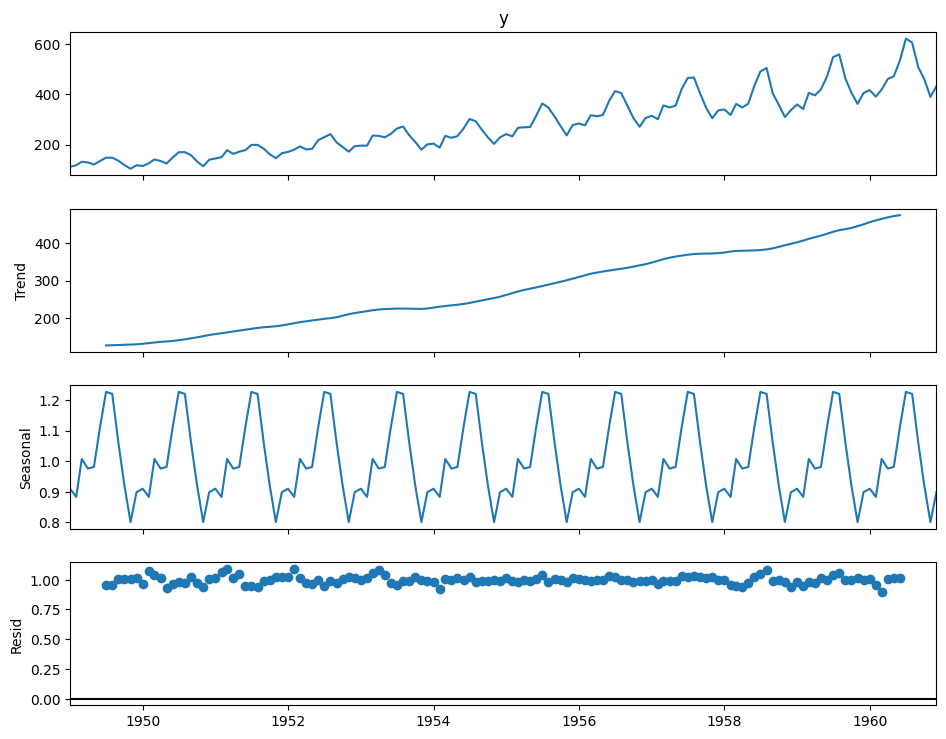

In [44]:
df = df.set_index('ds')
decomposition = sm.tsa.seasonal_decompose(df['y'], model='multiplicative', period=12)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

<Axes: xlabel='ds'>

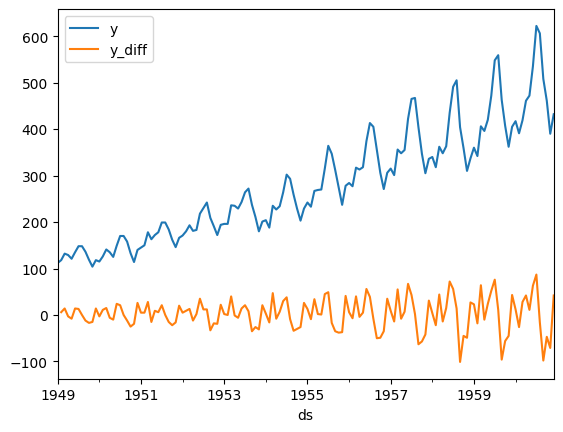

In [45]:
df_diff = df.copy()
df_diff['y_diff'] = df_diff['y'].diff()

df_diff.plot()



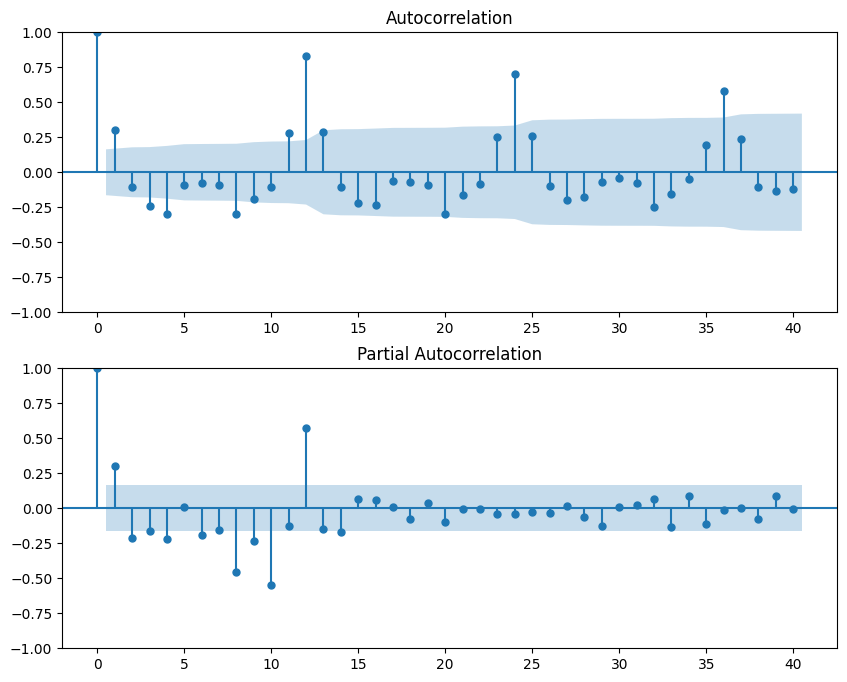

In [46]:
differenced_series = df['y'].diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(differenced_series, ax=ax1, lags=40)
plot_pacf(differenced_series, ax=ax2, lags=40)

plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -694.061
Date:                Thu, 17 Jul 2025   AIC                           1396.122
Time:                        13:09:53   BIC                           1407.973
Sample:                    02-01-1949   HQIC                          1400.937
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4507      3.441      0.712      0.476      -4.293       9.195
ar.L1         -0.4767      0.128     -3.735      0.000      -0.727      -0.227
ma.L1          0.8645      0.080     10.743      0.0

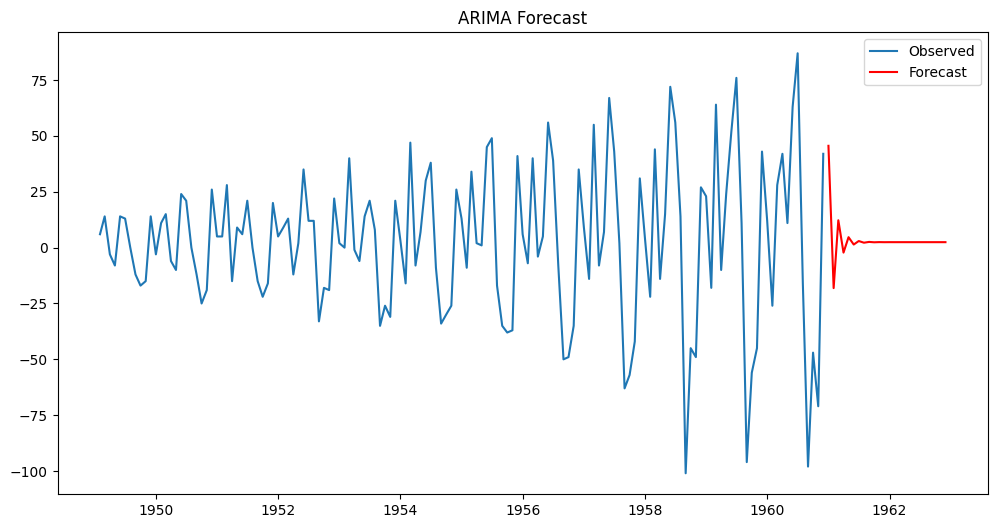

In [47]:
model = sm.tsa.ARIMA(differenced_series, order=(1, 0, 1))
results = model.fit()

# Print the model summary
print(results.summary())

# Generate forecasts
forecast_steps = 24
forecast = results.forecast(steps=forecast_steps)

# Plot the original series and the forecast
plt.figure(figsize=(12, 6))
plt.plot(differenced_series, label='Observed')
plt.plot(forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()

## Model Fitting Using `StatsForecast`

In [57]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.utils import AirPassengersDF

df = AirPassengersDF
sf = StatsForecast(
    models=[AutoARIMA(season_length = 12)],
    freq='MS',
)
sf.fit(df)
forecast_df = sf.predict(h=12, level=[90])
forecast_df.tail()

,unique_id,ds,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90
7,1.0,1961-08-01,633.236374,590.009004,676.463744
8,1.0,1961-09-01,535.236400,489.558889,580.913911
9,1.0,1961-10-01,488.236392,440.233792,536.238991
10,1.0,1961-11-01,417.236394,367.016191,467.456597
11,1.0,1961-12-01,459.236394,406.892468,511.580319


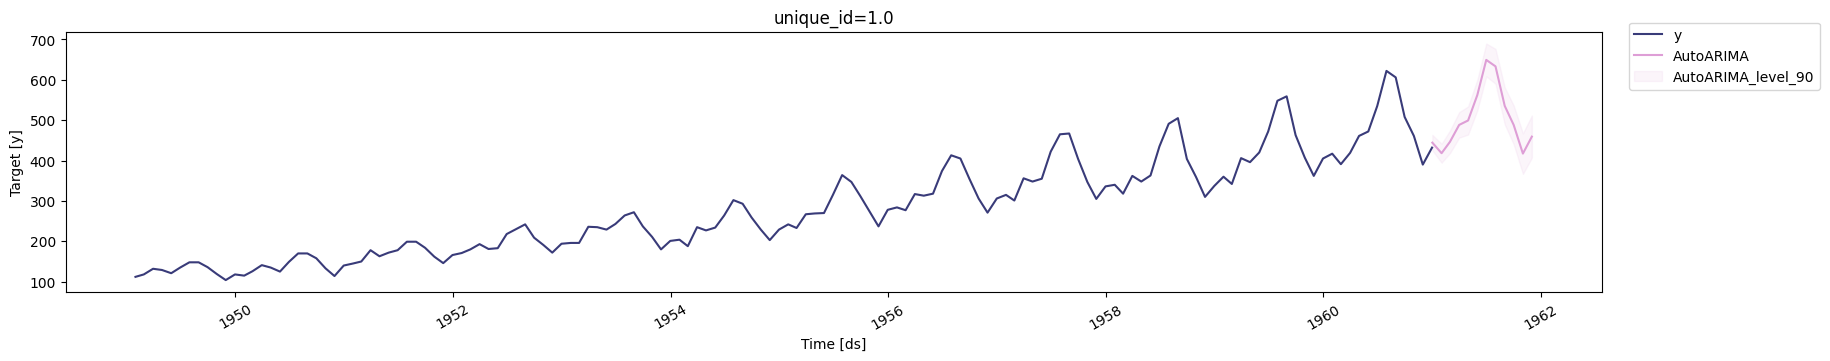

In [58]:
sf.plot(df, forecast_df, level=[90])